# KL 散度

## 定义

### 离散形式
对于两个离散概率分布 P  和 Q ：

$D_{KL}(P∥Q)=∑_{x∈X}P(x)log\frac{P(x)}{Q(x)}$

### 连续形式
$D_{KL}(P∥Q)=∫_{−∞}^{+∞}p(x)log\frac{p(x)}{q(x)}dx $
 
### 核心要素

| 符号                       | 含义              | 角色             |
| ------------------------ | --------------- | -------------- |
| P（或 p）               | **真实分布** / 参考分布 | "实际发生的"        |
| Q（或 q）               | **近似分布** / 模型分布 | "我猜的"          |
| $\log \frac{P(x)}{Q(x)}$ | **对数似然比**       | "实际 vs 猜测 的差异" |
| P(x) 作为权重              | **期望**          | "按真实频率加权平均"    |


## 信息论解释：编码的代价
### 核心直觉
- KL 散度 = "用 Q 来编码来自 P 的数据，比用 P 本身编码，多浪费多少比特"

| 场景       | 最优编码      | 实际编码      | 浪费             |
| -------- | --------- | --------- | -------------- |
| 数据来自 P | 用 P 的编码 | 用 Q 的编码 | D_{KL}(P\|Q) |

### 具体例子
假设
- 真实分布 P  
- 近似分布 Q ：

In [ ]:
事件    P(真实)    Q(猜测)    编码长度(-logQ)    最优长度(-logP)
─────────────────────────────────────────────────────────────────
A       0.5        0.5        1 bit              1 bit
B       0.3        0.2        2.32 bit           1.74 bit
C       0.2        0.3        1.74 bit           2.32 bit

D_KL(P||Q) = 0.5×log(0.5/0.5) + 0.3×log(0.3/0.2) + 0.2×log(0.2/0.3)
           = 0 + 0.3×0.585 + 0.2×(-0.585)
           ≈ 0.058 bit

**含义**：如果我用 Q(猜测)  的编码方案来传 P(真实)  的数据，平均每个符号多浪费 0.058 比特。

## 关键性质
### 非负性（Gibbs 不等式）
- $D_{KL}(P∥Q)≥0 $
- 等号成立 当且仅当 P=Q （几乎处处）

证明：利用 Jensen 不等式，−log  是凸函数。

### 不对称性（核心特征！）

$D_KL(P∥Q) ≠ D_KL(Q∥P) $
- 这是 KL 散度最重要的特性，**也是最容易被误解的地方**。

### 不是真正的"距离"

| 度量要求                          | KL 散度 | 满足？    |
| ----------------------------- | ----- | ------ |
| 非负性                           | ✓     | 是      |
| 同一性（$d=0 \Leftrightarrow$ 相同） | ✓     | 是      |
| 对称性                           | ✗     | **否！** |
| 三角不等式                         | ✗     | 否      |


- **KL 散度是 "散度（divergence）"** <font color='red'>而非 "距离（distance/metric）"</font>

## 不对称性的深层含义
### <font color='red'>两个方向的直观解释</font>

| 方向               | 公式                       | 含义                      | 惩罚什么                   |
| ------------------ | ------------------------ | ----------------------- | ---------------------- |
| D_{KL}(P\|Q) | $\sum P \log\frac{P}{Q}$ | **"Q 漏掉了 P 中哪些高频事件"**   | <font color='red'>Q 给 P 的高概率事件分配了低概率 </font>|
| D_{KL}(Q\|P) | \sum Q \log\frac{Q}{P} | **"Q 虚构了 P 中哪些不存在的事件"** | <font color='red'>Q 给 P 的低概率事件分配了高概率</font> |


### 可视化理解

In [3]:
from IPython.display import Image

In [ ]:
真实分布 P:     [■■■■■□□□□□]  集中在左侧
近似分布 Q1:    [■■■■■■□□□□]  稍微右偏
近似分布 Q2:    [□□□□□■■■■■]  完全相反

D_KL(P||Q1) = 小    ← Q1 基本覆盖了 P 的高概率区域
D_KL(P||Q2) = 大    ← Q2 完全错过了 P 的高概率区域

但：
D_KL(Q2||P) = 也大  ← 从 Q2 角度看，P 也错过了 Q2 的高概率区域

### 在机器学习中的体现


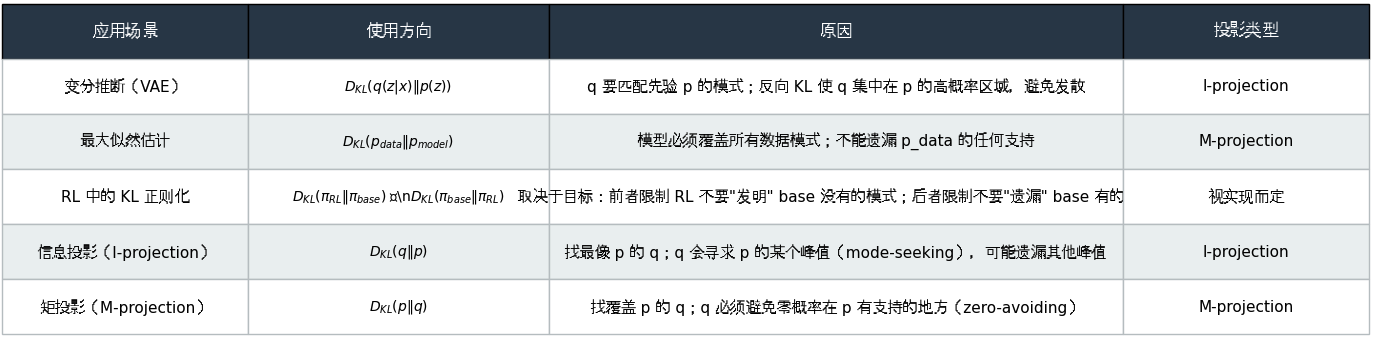

In [4]:
Image(filename='./kl.png')

## 与交叉熵和熵的关系
### 分解公式

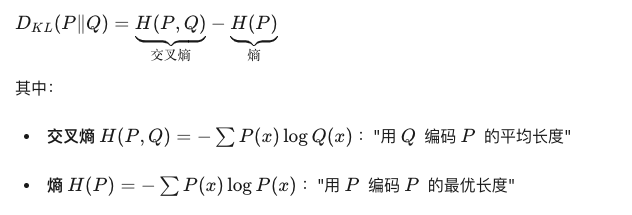

In [2]:
Image(filename='./entropy.png')

### 在神经网络中的应用 
- 分类任务的交叉熵损失，本质上就是 KL 散度

In [ ]:
神经网络做分类：
  输出：softmax 概率 Q = [0.1, 0.7, 0.2]
  标签：one-hot P = [0, 1, 0]

交叉熵损失 = -Σ P log Q = -log(0.7) ≈ 0.357

= H(P)       + D_KL(P||Q)
= 0 (one-hot) + 0.357

所以：最小化交叉熵 = 最小化 KL 散度（因为 H(P) 是常数）

## 在 "Sparse but Critical" 和 "RL's Razor" 中的应用
### RL's Razor 中的前向 KL
$D_{KL}(π_0 || π ) = E_{x \~ π_0}[log\frac{π_0(x)}{π(x)}]$

| 方向                     | 含义                       | 作用                               |
| ---------------------- | ------------------------ | -------------------------------- |
| D_{KL}(π_0 \| π ) | **前向 KL** / M-projection | 要求 $\pi$ **覆盖** $\pi_0$ 的所有高概率区域 |
| D_{KL}(π \| π_0 ) | **反向 KL** / I-projection | 要求 $\pi$ **集中在** $\pi_0$ 的高概率区域  |

- RL's Razor 的核心发现：
  - RL 隐式最小化的是 前向 KL 
$D_{KL}(π_0∥π)$ ，这解释了为什么 RL 遗忘更少——它要求新策略不要"遗漏" base 模型的任何能力。

### Sparse but Critical 中的使用
论文中 JS 散度的定义：

$D_{JS}(P||Q) = \frac{1}{2}D_{KL}(P||M) + \frac{1}{2}D_{KL}(Q||M) $

这里 KL 是构建块：
- 衡量 P  到平均分布 M  的距离
- 衡量 Q  到平均分布 M  的距离
- 取平均 → 对称化

## KL 散度的计算示例
###  两个伯努利分布

In [ ]:
P: 正面概率 p = 0.9
Q: 正面概率 q = 0.5

D_KL(P||Q) = 0.9×log(0.9/0.5) + 0.1×log(0.1/0.5)
           = 0.9×0.848 + 0.1×(-1.609)
           ≈ 0.763 - 0.161
           ≈ 0.602 bit

D_KL(Q||P) = 0.5×log(0.5/0.9) + 0.5×log(0.5/0.1)
           = 0.5×(-0.848) + 0.5×1.609
           ≈ -0.424 + 0.804
           ≈ 0.380 bit

D_KL(P||Q) ≠ D_KL(Q||P)  ✓ 不对称性验证

### 极端情况：零概率
- 这就是为什么 JS 散度（<font color='red'>用平均分布 M 避免零概率</font>）在比较分布时更安全。

In [ ]:
P = [1, 0]      (确定性：一定是 A)
Q = [0.5, 0.5]  (均匀猜测)

D_KL(P||Q) = 1×log(1/0.5) + 0×log(0/0.5)
           = log(2) + 0
           = 0.693 bit

但：
D_KL(Q||P) = 0.5×log(0.5/1) + 0.5×log(0.5/0)
           = 0.5×(-0.693) + 0.5×(+∞)
           = +∞  ← 发散！

原因：Q 认为 B 可能发生（概率0.5），但 P 说 B 绝对不可能（概率0）
      从 Q 看 P，P "遗漏"了 Q 的高概率事件 → 无限惩罚

## 一句话总结
- KL 散度衡量"用错误分布 Q 编码真实分布 P 的数据，**多浪费多少信息**"
- <font color='red'>它不对称、无界、要求绝对连续，但信息论意义深刻，是机器学习中衡量分布差异的基石</font>


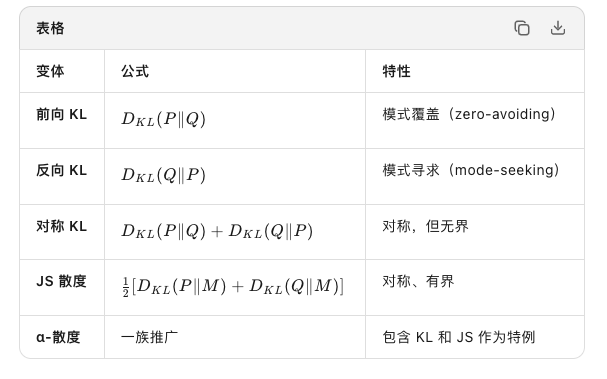

In [5]:
Image(filename='./kls.png')

# 前向KL散度与反向KL散度

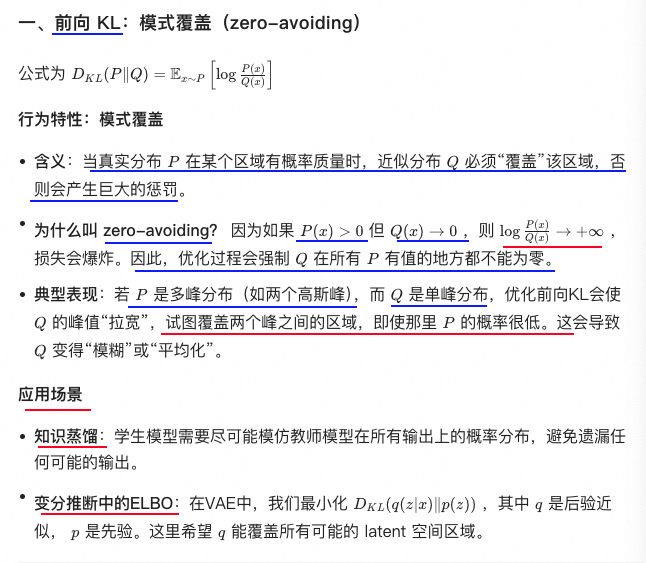

In [6]:
Image(filename='./kl1.png')

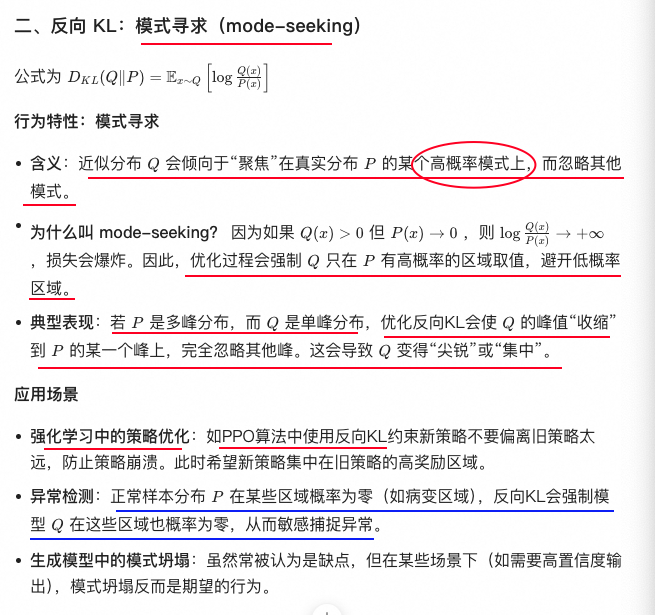

In [7]:
Image(filename='./kl2.png')

## 直观对比图示（文字版）

假设真实分布 P 是两个分离的高斯峰（双峰分布），我们用单峰高斯 Q 去拟合它：
- 前向 KL 优化结果： 
  - Q 的均值位于两个峰之间，方差较大，试图“覆盖”两个峰，但每个峰的密度都被稀释。
- 反向 KL 优化结果： 
  - Q 的均值落在其中一个峰上，方差较小，<font color='red'>完全忽略另一个峰，只“寻求”一个模式。</font>

## <font color='red'>为什么方向如此重要？</font>

<font color='blue'>KL散度的非对称性是其核心价值所在</font>。选择哪个方向取决于你的目标：
- 如果你希望模型“**不遗漏任何东西**”，选前向KL。
- 如果你希望模型<font color='red'>“专注在高概率区域”</font>，选反向KL。

**在大模型知识蒸馏中，研究发现:**
- 前向KL更适合让学生模型全面学习教师模型的输出分布；
- 而在强化学习中，反向KL更能保证策略的稳定性和安全性。

# 前向 KL 和反向 KL 的本质区别

## 设定场景
假设真实分布 P  是一个双峰分布（比如数据中有两类模式）：
- 我们用单峰分布 Q  去近似 P （比如模型容量有限，只能记住一个模式）：

In [10]:
P = [0.5, 0.5, 0, 0, 0]   ← 两个峰值（位置1和2），其余为零
         ↑↑

SyntaxError: invalid character '←' (U+2190) (2329837586.py, line 1)

## 前向 KL：$D _{KL}(P∥Q)$ —— 模式覆盖（zero- avoiding）
### 优化目标
$min_QD_{KL}(P∥Q)= ∑_iP(i)log\frac{P(i)}{Q(i)} $

 
### 关键行为

| P(i) | Q(i) | 贡献                                 |
| ------ | ------ | ---------------------------------- |
| 0.5    | 0.5    | log(1) = $                      |
| 0.5    | 0      | log(∞) = +∞ ← **爆炸！** |
| 0      | 0      | 无贡献                                |


### 结果
**Q  必须满足(覆盖)**：<font color='red'>P  有概率的地方，Q  必须有概率</font>


In [ ]:
P:      [■■, ■■, □, □, □]   ← 两个峰
        ↓
Q:      [■, ■, □, □, □]     ← 被迫覆盖两个峰（即使自己是单峰）
              ↑
              在两个峰之间"摊平"，形成覆盖

### 可视化：

In [ ]:
P 的真实分布:          Q 的近似结果:
   ▲                      ▲
  ■■                     ■
 ■  ■                   ■ ■
───────→               ───────→
 1  2                  1   2

双峰                   被迫在两个峰之间平均

###  特性：Zero-Avoiding（避零）

- P>0  的地方，Q  绝对不能为 0，否则 KL = ∞ 

## 反向 KL：$D_KL(Q∥P) $—— 模式寻求（mode-seeking）
### 优化目标

$ min_QD_{KL}(Q∥P)= ∑_iQ(i)log\frac{Q(i)}{P(i)} $ 


 
### 关键行为

| Q(i) | P(i) | 贡献                                          |
| ------ | ------ | ------------------------------------------- |
| 0.5    | 0.5    | log(1) = 0                               |
| 0      | 0.5    | 0 ⋅ log(0) = 0 ← **可以忽略！**           |
| 0.5    | 0      | log(∞) = +∞ ← 但 Q 不会主动放概率在这里 |


### 结果
<font color='red'>Q  会选择其中一个峰，完全忽略另一个</font>：

In [ ]:
P:      [■■, ■■, □, □, □]   ← 两个峰
        ↓
Q:      [■■, □, □, □, □]     ← 只抓住一个峰，另一个完全不管
        或
Q:      [□, ■■, □, □, □]     ← 只抓住另一个峰

### 可视化：

In [ ]:
P 的真实分布:          Q 的近似结果:
   ▲                      ▲
  ■■                     ■
 ■  ■                   ■ ■
───────→               ───────→
 1  2                  1   2

双峰                   只匹配其中一个峰

### 特性：Mode-Seeking（寻峰）
Q  只在乎自己放概率的地方 P  有没有概率，P  的其他峰可以被完全忽略


## 直观对比图

In [ ]:
                    前向 KL (P||Q)          反向 KL (Q||P)
                    ──────────────          ──────────────
                    
P (真实):           ■■  ■■                 ■■  ■■
                   /      \               /      \
                  ■        ■             ■        ■

Q (近似):           ■  ■  ■                ■■
                   (覆盖两个峰)            (只抓一个峰)
                   
行为:               "不能漏掉任何一个"      "抓住一个最像的就行"
                   
风险:               可能产生虚假的中间模式    可能完全遗漏某些真实模式
                   
典型应用:           最大似然估计             VAE 的变分推断
                   M-projection            I-projection

### 具体数值例子

In [ ]:
P = [0.5, 0.5, 0, 0]    ← 两个等概率峰

候选 Q1 = [0.5, 0.5, 0, 0]   ← 完美匹配（但假设模型做不到）
候选 Q2 = [1, 0, 0, 0]       ← 只抓第一个峰
候选 Q3 = [0.25, 0.25, 0.5, 0] ← 错误地引入了第三个位置

### 前向 KL 计算
- 前向 KL 选择 Q3：即使 Q3 引入了虚假的第三个模式，但它没有遗漏 P 的任何峰。

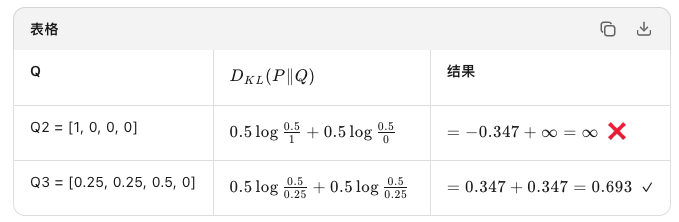

In [8]:
Image(filename='./k1_c.png')

### 反向 KL 计算
- 反向 KL 选择 Q2：<font color='red'>只抓住一个真实峰，完全忽略另一个</font>，但绝不引入虚假模式。

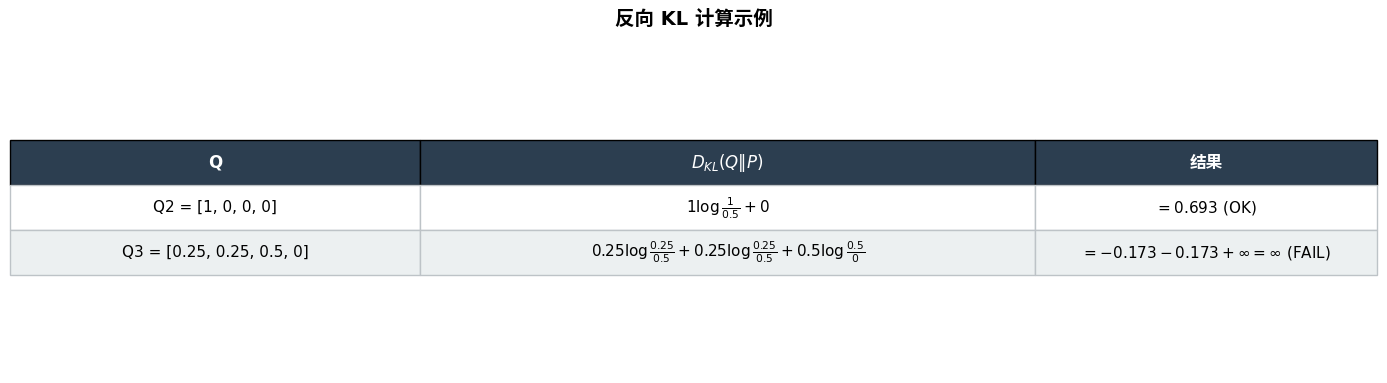

In [9]:
Image(filename='./k2_c.png')

## 在 RL 中的意义

| 方向        | 公式                               | 对 RL 策略的要求                             | 遗忘风险                     |
| --------- | -------------------------------- | -------------------------------------- | ------------------------ |
| **前向 KL** | D_KL(π_base \| π_RL) | <font color='red'>π_RL 必须**覆盖** π_base 的所有行为</font> | **低** —— 不会遗漏已有能力        |
| **反向 KL** | D_KL(π_RL \| π_base) | <font color='blue'>π_RL 只需在 π_base 支持的地方有概率 </font>   | **高** —— 可能遗忘 base 的某些模式 |

**"RL's Razor" 的发现**：
- <font color='red'>On-policy RL 隐式最小化的是**前向 KL**，所以遗忘更少——它强制新策略不能遗漏 base 模型的任何已有能力。</font>

## 一句话总结
- 前向 KL（P||Q）= "P 有的，Q 必须有" → 全覆盖，宁滥勿缺
- 反向 KL（Q||P）= "Q 有的，P 最好也有" → 抓重点，宁缺勿滥